## 1. Investigating the Raw KETI Sensor Data
Before analyzing the KETI sensor data, we must inspect the raw combined dataset. Because the 51 rooms use different sensors (Temperature/Humidity/Light/CO2 sampling every 5 seconds, and PIR sampling every 10 seconds), joining them on the exact timestamp creates a huge amount of staggered, misaligned rows. 

We load the raw combined data to observe this "outer join" effect.

In [22]:
import pandas as pd

raw_keti = pd.read_csv('../data/interim/combined_keti_sensor_data.csv', dtype={'room': str})

print(f"Raw Dataset Shape: {raw_keti.shape[0]:,} rows x {raw_keti.shape[1]} columns")
print("\nMissing Values (NaNs) caused by asynchronous sensor sampling:")
display(raw_keti.isna().sum())

display(raw_keti[raw_keti['room'] == '413'].head(10))

Raw Dataset Shape: 14,381,639 rows x 7 columns

Missing Values (NaNs) caused by asynchronous sensor sampling:


timestamp             0
room                  0
co2             7807631
humidity        7810174
light           7810176
pir            10787686
temperature     7810134
dtype: int64

,timestamp,room,co2,humidity,light,pir,temperature
0,2013-08-23 23:05:07,413,488.0,45.34,97.0,NaN,23.93
1,2013-08-23 23:05:08,413,495.0,45.34,97.0,0.0,23.94
2,2013-08-23 23:05:10,413,487.0,NaN,NaN,NaN,NaN
3,2013-08-23 23:05:26,413,NaN,45.34,97.0,0.0,23.93
4,2013-08-23 23:05:27,413,496.0,NaN,NaN,0.0,NaN
5,2013-08-23 23:05:30,413,495.0,NaN,NaN,0.0,NaN
6,2013-08-23 23:05:31,413,NaN,45.31,97.0,NaN,23.93
7,2013-08-23 23:05:34,413,500.0,NaN,NaN,NaN,NaN
8,2013-08-23 23:05:36,413,NaN,45.34,97.0,NaN,23.92
9,2013-08-23 23:05:39,413,495.0,NaN,NaN,0.0,NaN


## 2. PIR Mystery
 The Kaggle description says PIR indicates occupancy, but it doesn't specify if it's a binary 0/1 or something else. 
 So we check the range of PIR values

In [ ]:

print("PIR Statistics:")
display(raw_keti['pir'].describe())

# Look at the most frequent values
print("\nTop 10 most frequent PIR values:")
display(raw_keti['pir'].value_counts().head(10))

PIR Statistics:


count    3.593953e+06
mean     1.754301e+00
std      1.934540e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.445600e+04
Name: pir, dtype: float64


Top 10 most frequent PIR values:


pir
0.0     3337283
30.0     103452
29.0      25510
28.0      15855
27.0      11627
26.0       9270
25.0       7756
24.0       6743
23.0       6043
22.0       5431
Name: count, dtype: int64

In [26]:
print("Frequency of the highest PIR values:")
display(raw_keti['pir'].value_counts().sort_index(ascending=False).head(10))

Frequency of the highest PIR values:


pir
34456.0         1
30.0       103452
29.0        25510
28.0        15855
27.0        11627
26.0         9270
25.0         7756
24.0         6743
23.0         6043
22.0         5431
Name: count, dtype: int64

In [16]:
print("Data 6 Ranges:")
print(raw_keti.describe())

print(f"Max PIR value in raw data: {raw_keti['pir'].max()}")
occupied_count = (raw_keti['pir'] > 0).sum()
print(f"Total non-zero PIR readings: {occupied_count:,}")

Data 6 Ranges:
                co2      humidity         light           pir   temperature
count  6.574008e+06  6.571465e+06  6.571463e+06  3.593953e+06  6.571505e+06
mean   4.110066e+02  5.674771e+01  8.226156e+01  1.754301e+00  2.397020e+01
std    1.035154e+02  4.307900e+00  3.101547e+02  1.934540e+01  2.119168e+01
min    8.000000e+00 -5.009600e+02  0.000000e+00  0.000000e+00 -4.010000e+01
25%    3.520000e+02  5.398000e+01  3.000000e+00  0.000000e+00  2.253000e+01
50%    4.100000e+02  5.701000e+01  5.000000e+00  0.000000e+00  2.311000e+01
75%    4.630000e+02  5.974000e+01  3.000000e+01  0.000000e+00  2.371000e+01
max    1.699000e+03  7.191000e+01  3.055100e+04  3.445600e+04  5.792700e+02
Max PIR value in raw data: 34456.0
Total non-zero PIR readings: 256,670


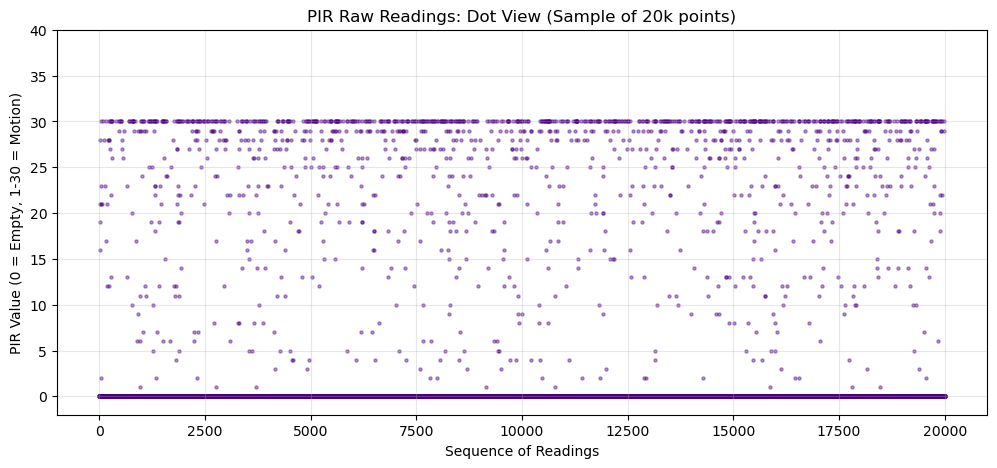

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load a sample so it plots quickly (14M dots would crash your screen!)
raw_pir = pd.read_csv('../data/interim/combined_keti_sensor_data.csv', usecols=['pir']).dropna()
sample_df = raw_pir.sample(20000, random_state=42).reset_index()

plt.figure(figsize=(12, 5))

# Plotting with dots (scatter)
plt.scatter(sample_df.index, sample_df['pir'], alpha=0.4, s=5, c='indigo')

# Set the limit to 40 so the 34,000 glitch doesn't squish the dots
plt.ylim(-2, 40) 

plt.title('PIR Raw Readings: Dot View (Sample of 20k points)')
plt.xlabel('Sequence of Readings')
plt.ylabel('PIR Value (0 = Empty, 1-30 = Motion)')
plt.grid(True, alpha=0.3)
plt.show()

### The Solution: Time-Series Resampling
The output above confirms that while no data was lost, the asynchronous sensors created millions of rows with missing values (e.g., PIR is missing exactly half the time because of its 10-second sampling rate).

To fix these "typos in time", the data will be resampled into consistent **1-minute intervals**. 
* **Continuous features** (Temperature, Humidity, Light, CO2) were aggregated using their `mean`.
* **Occupancy (PIR)**: To handle the non-binary raw values (0.0–30.0) and the 34,456.0 glitch, we first binarized the data by setting any value > 0 to 1. We then aggregate using max; if motion was detected at any point during that 60-second window, the entire minute is marked as occupied.

*Note: Check out scripts folder, this resampling was handled (`scripts/resample_keti_data.py`) to generate a clean, lightweight `interim` dataset.*

In [ ]:
data_6 = pd.read_csv('../data/interim/keti_1min_resampled.csv', dtype={'room': str})
data_6['timestamp'] = pd.to_datetime(data_6['timestamp'])

print(f"Resampled Dataset Shape: {data_6.shape[0]:,} rows x {data_6.shape[1]} columns")
print("\nMissing Values after 1-minute resampling:")
display(data_6.isna().sum())

data_6.head()

Resampled Dataset Shape: 604,895 rows x 7 columns

Missing Values after 1-minute resampling:


room           0
timestamp      0
co2            0
humidity       0
light          0
temperature    0
pir            0
dtype: int64

,room,timestamp,co2,humidity,light,temperature,pir
0,413,2013-08-23 23:05:00,494.727273,45.3300,96.555556,23.927778,0.0
1,413,2013-08-23 23:06:00,496.666667,45.3275,96.833333,23.938333,0.0
2,413,2013-08-23 23:07:00,498.916667,45.3250,97.333333,23.942500,0.0
3,413,2013-08-23 23:08:00,504.166667,45.3125,97.083333,23.952500,0.0
4,413,2013-08-23 23:09:00,499.500000,45.3100,97.416667,23.955833,0.0
